In [1]:
from utils.models import FastPolicyNet, StrongPolicyNet
from utils.coin_env import coin_game
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import pickle
import psutil
import time
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [2]:
env = coin_game()

def expert(env):
    """Agen Pakar dengan strategi optimal matematika murni (Nim Game)."""
    if env.state % 4 != 1:
        return (env.state - 1) % 4  # Ambil koin menuju posisi aman (4n + 1)
    return random.choice([1, 2, 3])  # Langkah acak jika berada di posisi kalah

def non_expert(env):
    """Agen Amatir dengan 50% peluang optimal dan 50% peluang acak/salah."""
    if env.state % 4 != 1 and np.random.rand() < 0.5:
        return (env.state - 1) % 4  # Pilihan optimal
    return random.choice([1, 2, 3])  # Pilihan acak

def one_game(episode):
    """Mensimulasikan satu sesi game penuh dan merekam langkah Expert."""
    history = []
    state = env.reset()
    
    # Paritas giliran awal: Genap (Expert duluan), Ganjil (Non-Expert duluan)
    if episode % 2 == 0:
        action = expert(env)
        history.append((state, action))  # Rekam pasangan (state, action) expert
        state, _, done, _ = env.step(action)
        if done: return history
            
    while True:
        # --- Giliran Non-Expert (Lawan) ---
        action = non_expert(env)
        state, _, done, _ = env.step(action)
        if done: break
            
        # --- Giliran Expert (Agen Target) ---
        action = expert(env)
        history.append((state, action))  # Rekam data demonstrasi expert
        state, _, done, _ = env.step(action)
        if done: break
            
    return history

# --- EKSEKUSI PIPELINE & SERIALISASI DATA ---
results = []        
for episode in range(10000):  # Simulasi 10.000 episode untuk dataset masif
    results += one_game(episode)

# Serialisasi (Save) dataset menggunakan Pickle
with open('utils/games_coin.p', 'wb') as fp:
    pickle.dump(results, fp)      

# Verifikasi (Load) dataset untuk memastikan file tidak korup
with open('utils/games_coin.p', 'rb') as fp:
    games = pickle.load(fp)

In [3]:
states = []
actions = []

# --- EKSTRAKSI & ENKODING DATASET (PREPROCESSING PIPELINE) ---
for x in games:
    states.append(x[0])     # Simpan kondisi sisa koin ke list states
    actions.append(x[1]-1)  # Konversi aksi (1,2,3) ke indeks (0,1,2) untuk CrossEntropy

# Konversi data ke format Tensor PyTorch
states = torch.tensor(states, dtype=torch.long)  # List state -> Tensor Long (Int64)

# One-Hot Encoding fitur (X) secara otomatis berbasis rentang 0-30 koin
X = F.one_hot(states, num_classes=31).float()

# Label target (y) untuk perhitungan loss function
y = torch.tensor(actions, dtype=torch.long)

Final Loss: 0.6243 | Accuracy: 91.97%


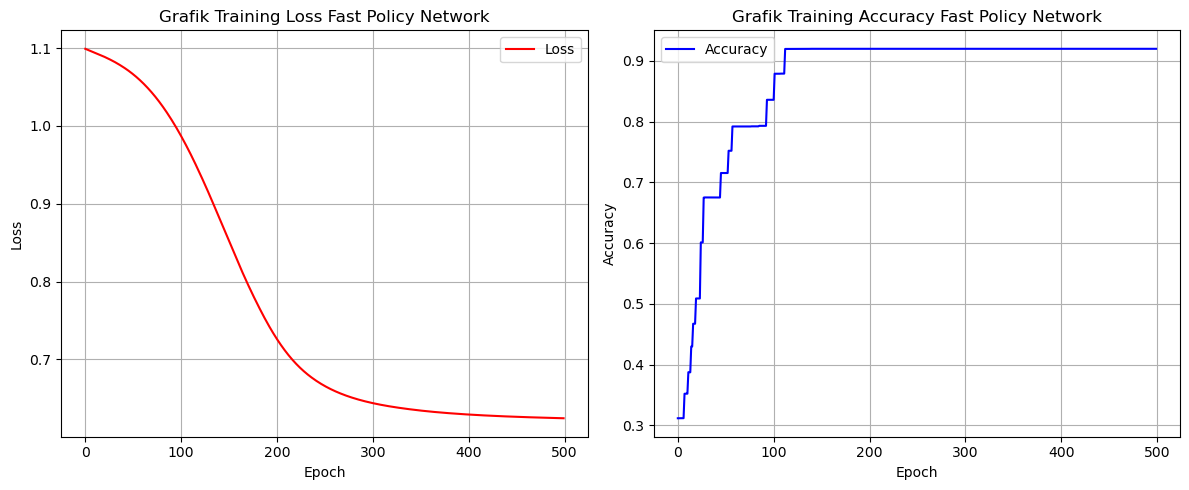

In [4]:
process = psutil.Process(os.getpid())
def get_ram_mb(): return process.memory_info().rss / 1024 / 1024

start_time = time.time()
ram_peak = get_ram_mb()
convergence_episode = "N/A"

fast_model = FastPolicyNet()
criterion = nn.CrossEntropyLoss()
optimizer_1 = optim.Adam(fast_model.parameters(), lr=0.001)

loss_history, acc_history = [], []
epochs = 500

# --- TRAINING LOOP FAST POLICY NETWORK ---
for epoch in range(epochs):
    optimizer_1.zero_grad()         # 1. Reset gradien dari iterasi sebelumnya
    outputs = fast_model(X)         # 2. Forward Pass: Prediksi probabilitas aksi
    loss = criterion(outputs, y)    # 3. Calculate Loss: Selisih prediksi vs expert
    loss.backward()                 # 4. Backward Pass: Hitung gradien parsial
    optimizer_1.step()              # 5. Parameter Update: Perbarui bobot model
    
    # Perhitungan Metrik Akurasi
    pred = torch.argmax(outputs, dim=1)
    acc_1 = (pred == y).float().mean()

    loss_history.append(loss.item())
    acc_history.append(acc_1.item())

# Simpan bobot parameter model (state_dict)
torch.save(fast_model.state_dict(), 'utils/fast_coin.pt')
print(f"Final Loss: {loss_history[-1]:.4f} | Accuracy: {acc_history[-1] * 100:.2f}%")

# --- VISUALISASI EVALUASI (MATPLOTLIB) ---
plt.figure(figsize=(12, 5))

# Plot Kiri: Perkembangan Nilai Loss
plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Loss', color='red')
plt.title('Grafik Training Loss Fast Policy Network')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True); plt.legend()

# Plot Kanan: Perkembangan Tingkat Akurasi
plt.subplot(1, 2, 2)
plt.plot(acc_history, label='Accuracy', color='blue')
plt.title('Grafik Training Accuracy Fast Policy Network')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(True); plt.legend()

plt.tight_layout()
plt.savefig("utils/training_fast.png", dpi=300, bbox_inches='tight')
plt.show()

end_time = time.time()
current_ram = get_ram_mb()
if current_ram > ram_peak: ram_peak = current_ram

In [5]:
print(f"\n=== METRIK EFISIENSI: Fast Policy Network ===")
print(f"Waktu Pelatihan   : {end_time - start_time:.2f} detik")
print(f"Episode Konvergen : {epochs} epoch (tetap)")
print(f"Puncak RAM        : {ram_peak:.2f} MB")


=== METRIK EFISIENSI: Fast Policy Network ===
Waktu Pelatihan   : 46.19 detik
Episode Konvergen : 500 epoch (tetap)
Puncak RAM        : 441.71 MB


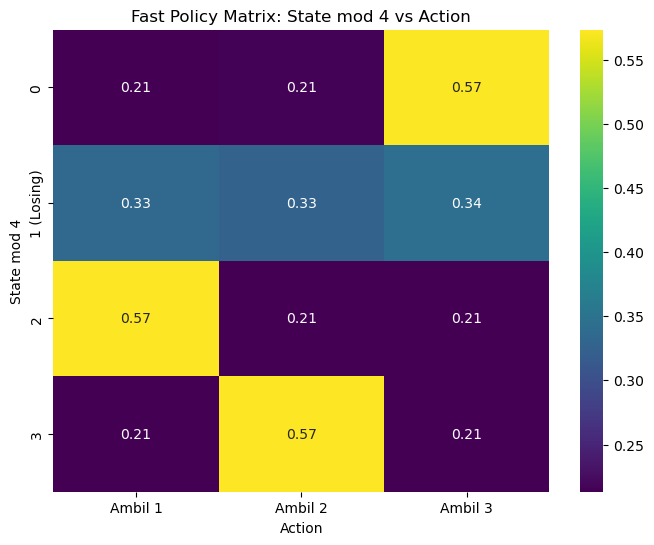

In [6]:
# Generasi representasi One-Hot untuk state legal (1-30 koin) secara manual
states = torch.FloatTensor([[1 if i == j else 0 for j in range(31)] for i in range(1, 31)])

# Jalankan model dalam mode evaluasi (inferensi tanpa hitung gradien)
fast_model.eval()
with torch.no_grad():
    logits = fast_model(states)
    probs = torch.softmax(logits, dim=1).numpy()  # Distribusi probabilitas aksi

# Matriks kontingensi: 4 karakteristik modulo (baris) x 3 pilihan aksi (kolom)
policy_matrix = np.zeros((4, 3))
counts = np.zeros(4)

# --- Agregasi Distribusi Probabilitas Berdasarkan Modulo 4 ---
for i, p in enumerate(probs):
    state_val = i + 1                  # Konversi indeks array ke nilai koin asli (1-30)
    m = state_val % 4                  # Klasifikasi karakteristik state (Teori Nim)
    policy_matrix[m] += p              # Akumulasi probabilitas keputusan model
    counts[m] += 1                     # Hitung frekuensi kemunculan kelas modulo

# Normalisasi Baris (Menghitung Rata-Rata Probabilitas)
for i in range(4):
    if counts[i] > 0:
        policy_matrix[i] /= counts[i]
        
# --- VISUALISASI MATRIKS STRATEGI (HEATMAP GENERATION) ---
plt.figure(figsize=(8, 6))
sns.heatmap(policy_matrix, annot=True, cmap='viridis', 
            xticklabels=['Ambil 1', 'Ambil 2', 'Ambil 3'],
            yticklabels=['0', '1 (Losing)', '2', '3'])

plt.title('Fast Policy Matrix: State mod 4 vs Action')
plt.xlabel('Action'); plt.ylabel('State mod 4')
plt.savefig("utils/policy_matrix_fast.png", dpi=300, bbox_inches='tight')
plt.show()

Final Loss: 0.6185 | Accuracy: 91.97%


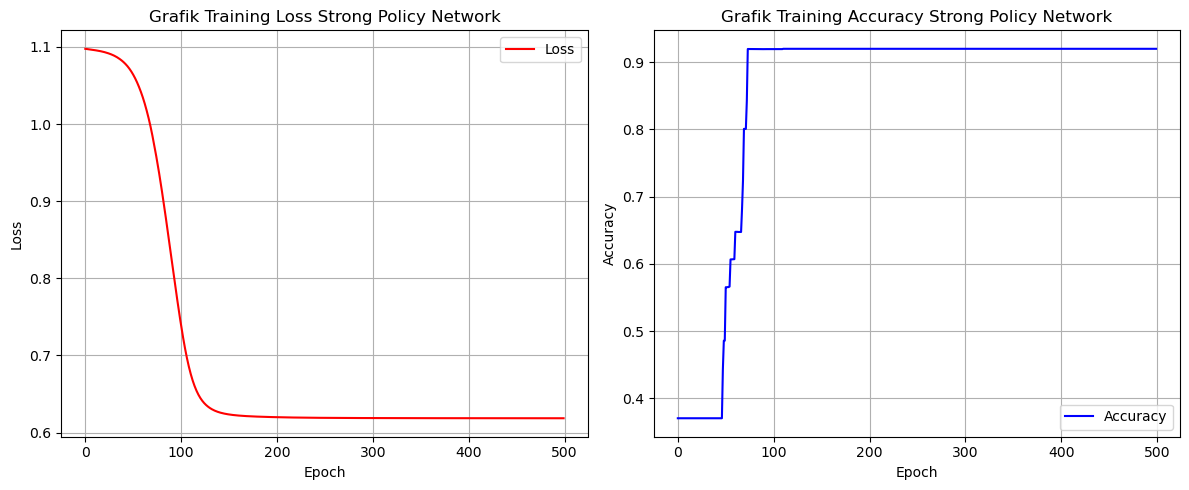

In [7]:
start_time = time.time()
ram_peak = get_ram_mb()
convergence_episode = "N/A"

strong_model = StrongPolicyNet()
criterion = nn.CrossEntropyLoss()
optimizer_2 = optim.Adam(strong_model.parameters(), lr=0.001)

loss_history, acc_history = [], []
epochs = 500

# --- TRAINING LOOP STRONG POLICY NETWORK ---
for epoch in range(epochs):
    optimizer_2.zero_grad()         # 1. Reset gradien dari iterasi sebelumnya
    outputs = strong_model(X)       # 2. Forward Pass: Prediksi pada jaringan mendalam
    loss = criterion(outputs, y)    # 3. Calculate Loss: Selisih prediksi vs expert
    loss.backward()                 # 4. Backward Pass: Hitung gradien balik balik
    optimizer_2.step()              # 5. Parameter Update: Perbarui parameter model
    
    # Perhitungan Metrik Akurasi
    pred = torch.argmax(outputs, dim=1)
    acc_2 = (pred == y).float().mean()

    loss_history.append(loss.item())
    acc_history.append(acc_2.item())

# Simpan bobot parameter model mendalam (state_dict)
torch.save(strong_model.state_dict(), 'utils/strong_coin.pt')
print(f"Final Loss: {loss_history[-1]:.4f} | Accuracy: {acc_history[-1] * 100:.2f}%")

# --- VISUALISASI EVALUASI (MATPLOTLIB) ---
plt.figure(figsize=(12, 5))

# Plot Kiri: Perkembangan Nilai Loss
plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Loss', color='red')
plt.title('Grafik Training Loss Strong Policy Network')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True); plt.legend()

# Plot Kanan: Perkembangan Tingkat Akurasi
plt.subplot(1, 2, 2)
plt.plot(acc_history, label='Accuracy', color='blue')
plt.title('Grafik Training Accuracy Strong Policy Network')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(True); plt.legend()

plt.tight_layout()
plt.savefig("utils/training_strong.png", dpi=300, bbox_inches='tight')
plt.show()

end_time = time.time()
current_ram = get_ram_mb()
if current_ram > ram_peak: ram_peak = current_ram

In [8]:
print(f"\n=== METRIK EFISIENSI: Strong Policy Network ===")
print(f"Waktu Pelatihan   : {end_time - start_time:.2f} detik")
print(f"Episode Konvergen : {epochs} epoch (tetap)")
print(f"Puncak RAM        : {ram_peak:.2f} MB")


=== METRIK EFISIENSI: Strong Policy Network ===
Waktu Pelatihan   : 97.48 detik
Episode Konvergen : 500 epoch (tetap)
Puncak RAM        : 499.96 MB


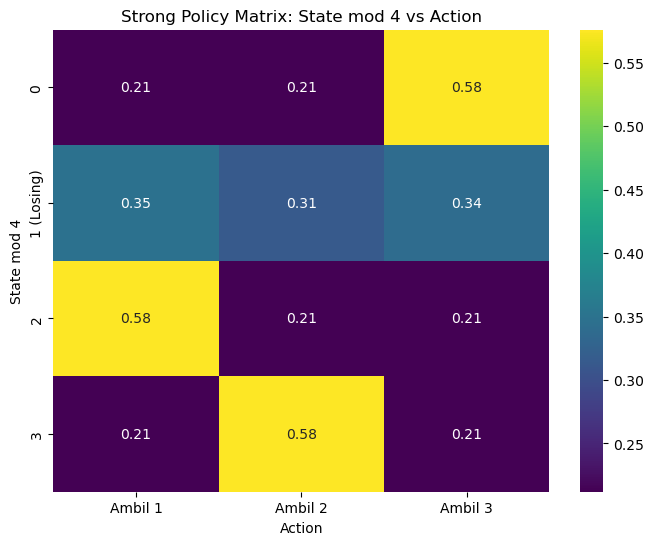

In [9]:
# Generasi representasi One-Hot untuk state legal (1-30 koin) secara manual
states = torch.FloatTensor([[1 if i == j else 0 for j in range(31)] for i in range(1, 31)])

# Jalankan model dalam mode evaluasi (inferensi tanpa hitung gradien)
strong_model.eval()
with torch.no_grad():
    logits = strong_model(states)
    probs = torch.softmax(logits, dim=1).numpy()  # Distribusi probabilitas aksi

# Matriks kontingensi: 4 karakteristik modulo (baris) x 3 pilihan aksi (kolom)
policy_matrix = np.zeros((4, 3))
counts = np.zeros(4)

# --- Agregasi Distribusi Probabilitas Berdasarkan Modulo 4 ---
for i, p in enumerate(probs):
    state_val = i + 1                  # Konversi indeks array ke nilai koin asli (1-30)
    m = state_val % 4                  # Klasifikasi karakteristik state (Teori Nim)
    policy_matrix[m] += p              # Akumulasi probabilitas keputusan model mendalam
    counts[m] += 1                     # Hitung frekuensi kemunculan kelas modulo

# Normalisasi Baris (Menghitung Rata-Rata Probabilitas)
for i in range(4):
    if counts[i] > 0:
        policy_matrix[i] /= counts[i]
        
# --- VISUALISASI MATRIKS STRATEGI STRONG MODEL (HEATMAP) ---
plt.figure(figsize=(8, 6))
sns.heatmap(policy_matrix, annot=True, cmap='viridis', 
            xticklabels=['Ambil 1', 'Ambil 2', 'Ambil 3'],
            yticklabels=['0', '1 (Losing)', '2', '3'])

plt.title('Strong Policy Matrix: State mod 4 vs Action')
plt.xlabel('Action'); plt.ylabel('State mod 4')
plt.savefig("utils/policy_matrix_strong.png", dpi=300, bbox_inches='tight')
plt.show()